## **IBOVESPA - Modelo Preditivo**
Desenvolver um modelo preditivo capaz de prever se o índice IBOVESPA vai fechar em alta ou baixa no dia seguinte, com base em dados históricos do próprio índice.

**Objetivo:** Modelo deve prever a tendência (↑ ou ↓) com acuracidade mínima de 75% em um conjunto de teste. O conjunto de testes deverá conter o último mês (30 dias) de dados disponíveis.

**Dados:** https://br.investing.com/indices/bovespa-historical-data

### 1. Importação de Bibliotecas e Configuração do Ambiente

In [1]:
import pandas as pd
import numpy as np
import warnings
import unicodedata

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Ocultar warnings emitidos pelas bibliotecas durante a execução do notebook
warnings.filterwarnings("ignore")

------------------------------------------------------------

### 2. Definição de Parâmetros e Carregamento dos Dados

In [2]:
file_path = "Dados Históricos - Ibovespa 2006.csv"
train_start_date = pd.to_datetime("2020-01-01")
target_threshold = 0.003
test_size = 30
cutoff_proba = 0.45

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

df_raw = pd.read_csv(file_path)
df_raw.head()

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,02.03.2026,189.307,188.786,190.110,186.638,"9,09B","0,28%"
1,27.02.2026,188.787,191.005,191.005,188.478,"11,00B","-1,16%"
2,26.02.2026,191.005,191.248,191.978,188.977,"8,80B","-0,13%"
3,25.02.2026,191.247,191.491,192.624,190.419,"9,13B","-0,13%"
4,24.02.2026,191.490,188.854,191.781,188.854,"11,04B","1,40%"


------------------------------------------------------------

### 3. Diagnóstico Inicial dos Dados

In [3]:
print("Shape:", df_raw.shape)
print("\nTipos das colunas:")
print(df_raw.dtypes)

print("\nValores nulos:")
print(df_raw.isnull().sum())

print("\nValores duplicados:")
print(df_raw.duplicated().sum())

display(df_raw)

display(df_raw.describe().T)

Shape: (4954, 7)

Tipos das colunas:
Data         object
Último      float64
Abertura    float64
Máxima      float64
Mínima      float64
Vol.         object
Var%         object
dtype: object

Valores nulos:
Data        0
Último      0
Abertura    0
Máxima      0
Mínima      0
Vol.        1
Var%        0
dtype: int64

Valores duplicados:
0


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,02.03.2026,189.307,188.786,190.110,186.638,"9,09B","0,28%"
1,27.02.2026,188.787,191.005,191.005,188.478,"11,00B","-1,16%"
2,26.02.2026,191.005,191.248,191.978,188.977,"8,80B","-0,13%"
3,25.02.2026,191.247,191.491,192.624,190.419,"9,13B","-0,13%"
4,24.02.2026,191.490,188.854,191.781,188.854,"11,04B","1,40%"
...,...,...,...,...,...,...,...
4949,08.03.2006,37.289,37.421,37.421,36.446,"139,70M","-0,36%"
4950,07.03.2006,37.423,38.350,38.350,37.130,"150,70M","-2,43%"
4951,06.03.2006,38.354,39.241,39.395,38.348,"125,16M","-2,26%"
4952,03.03.2006,39.240,39.129,39.356,38.716,"96,08M","0,29%"


,count,mean,std,min,25%,50%,75%,max
Último,4954.0,78.883589,31.746345,29.435,54.01400,66.1340,106.75775,191.490
Abertura,4954.0,78.853788,31.712739,29.438,54.01525,66.1270,106.73075,191.491
Máxima,4954.0,79.592206,31.878499,31.480,54.56700,66.7075,107.76700,192.624
Mínima,4954.0,78.136510,31.587155,29.435,53.45375,65.5330,105.84575,190.419


------------------------------------------------------------

### 4. Padronização dos Nomes das Colunas

In [4]:
def strip_accents(s):
    return ''.join(
        ch for ch in unicodedata.normalize('NFKD', s)
        if not unicodedata.combining(ch)
    )

def clean_col(c):
    return strip_accents(str(c)).replace('.', '').replace('%', '').lower().strip()

cols = {clean_col(c): c for c in df_raw.columns}
cols

{'data': 'Data',
 'ultimo': 'Último',
 'abertura': 'Abertura',
 'maxima': 'Máxima',
 'minima': 'Mínima',
 'vol': 'Vol.',
 'var': 'Var%'}

In [5]:
rename = {}

for k, v in cols.items():
    if "data" in k:
        rename[v] = "Date"
    elif "ultimo" in k or "fechamento" in k:
        rename[v] = "Close"
    elif "abert" in k:
        rename[v] = "Open"
    elif "max" in k:
        rename[v] = "High"
    elif "min" in k:
        rename[v] = "Low"
    elif "vol" in k:
        rename[v] = "Volume"

rename

{'Data': 'Date',
 'Último': 'Close',
 'Abertura': 'Open',
 'Máxima': 'High',
 'Mínima': 'Low',
 'Vol.': 'Volume'}

------------------------------

### 5. Tratamento e Preparação dos Dados

In [6]:
df = df_raw.rename(columns=rename).copy()

def coerce_pt_number(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().replace('.', '').replace(',', '.')
    try:
        return float(s)
    except:
        return np.nan

def parse_pt_volume(v):
    if pd.isna(v):
        return np.nan

    s = str(v).strip()
    mult = 1

    if s.endswith(("M", "m")):
        mult, s = 1e6, s[:-1]
    elif s.endswith(("K", "k")):
        mult, s = 1e3, s[:-1]
    elif s.endswith(("B", "b")):
        mult, s = 1e9, s[:-1]

    try:
        return float(s.replace('.', '').replace(',', '.')) * mult
    except:
        return np.nan

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

for col in ["Close", "Open", "High", "Low"]:
    if col in df.columns:
        df[col] = df[col].apply(coerce_pt_number)

if "Volume" in df.columns:
    df["Volume"] = df["Volume"].apply(parse_pt_volume)

df = df.dropna(subset=["Date"]).sort_values("Date").set_index("Date")
df.head()

,Close,Open,High,Low,Volume,Var%
Date,,,,,,
2006-03-02,39126.0,39182.0,39367.0,38989.0,86850000.0,"-0,13%"
2006-03-03,3924.0,39129.0,39356.0,38716.0,96080000.0,"0,29%"
2006-03-06,38354.0,39241.0,39395.0,38348.0,125160000.0,"-2,26%"
2006-03-07,37423.0,3835.0,3835.0,3713.0,150700000.0,"-2,43%"
2006-03-08,37289.0,37421.0,37421.0,36446.0,139700000.0,"-0,36%"


----------------------------------------

### 6. Análise da Distribuição das Variáveis Numéricas
Distribuições das variáveis numéricas da base, com o objetivo de identificar padrões de concentração, dispersão, assimetrias e possíveis comportamentos atípicos.

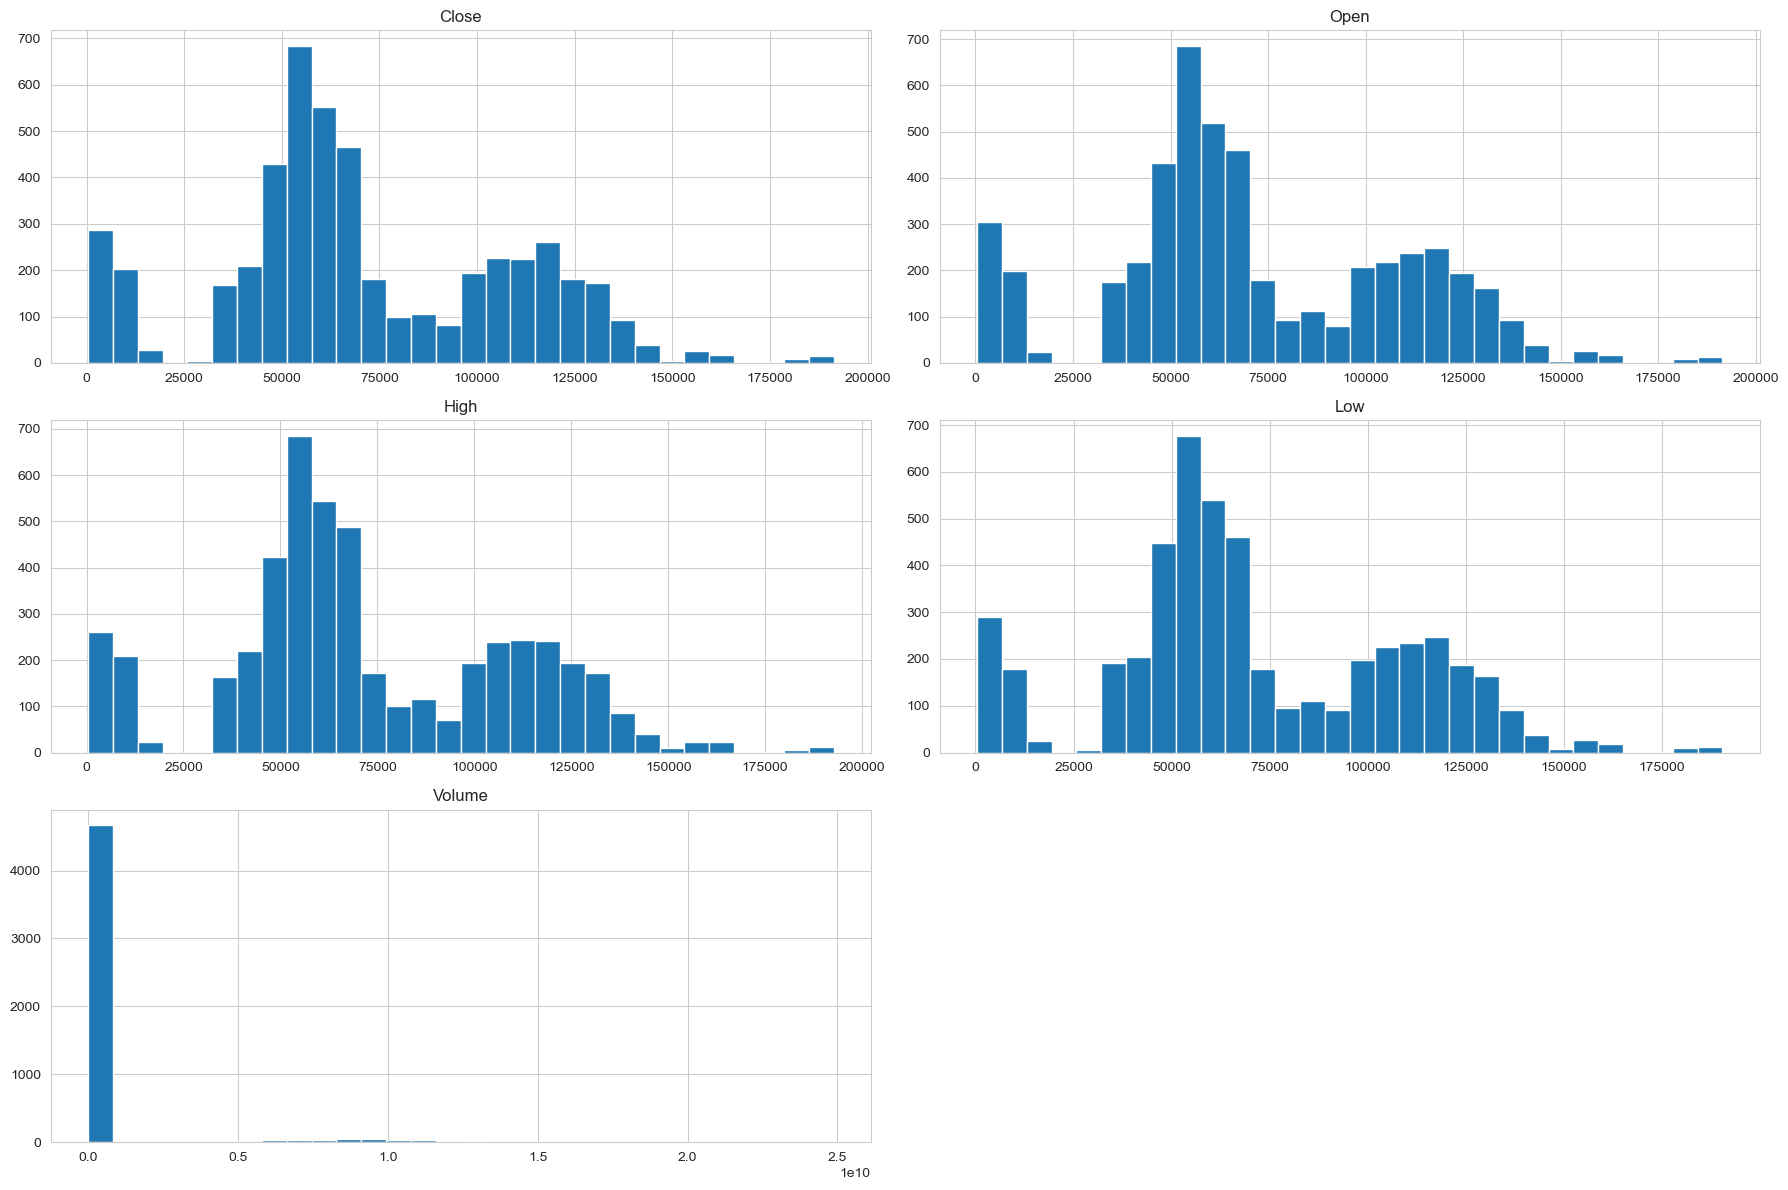

In [7]:
df.select_dtypes(include=np.number).hist(bins=30, figsize=(18, 12))
plt.tight_layout()
plt.show()

**Interpretação:**

Os histogramas das variáveis de preço (Open, High, Low e Close) apresentam distribuições semelhantes, o que é consistente com a natureza dessas medidas no mercado financeiro. Observa-se concentração dos valores em faixas específicas ao longo da série histórica, sugerindo que o Ibovespa operou em diferentes patamares no período analisado, em vez de oscilar em torno de um único nível central.

A variável Volume, por sua vez, apresenta distribuição fortemente assimétrica à direita, com elevada concentração em valores menores e poucos episódios de volume muito elevado. Esse comportamento é compatível com a dinâmica do mercado, em que momentos específicos de maior incerteza ou atividade podem gerar picos relevantes de negociação.

-------------------------------------------------

### 7. Análise de Outliers por Variável
Boxplots para avaliar a dispersão das variáveis numéricas e identificar possíveis valores extremos, contribuindo para o entendimento da variabilidade dos dados e de eventuais pontos atípicos que possam influenciar a análise e a modelagem.

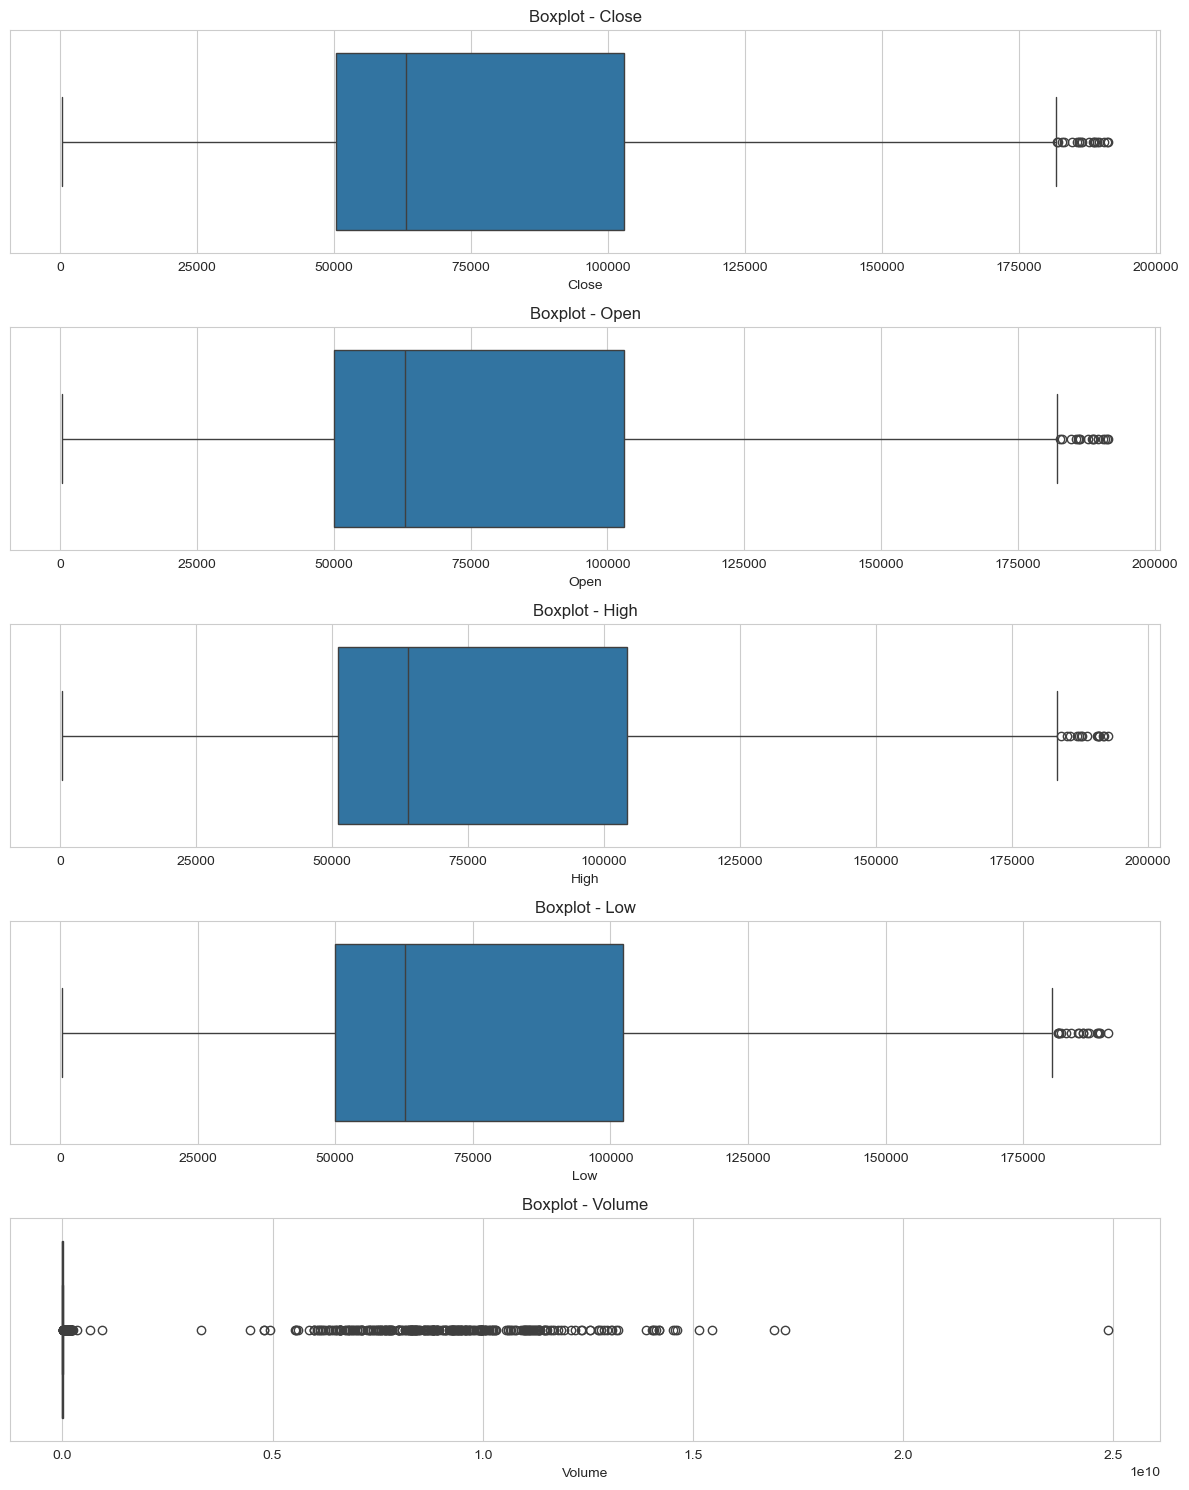

In [8]:
colunas_boxplot = ["Close", "Open", "High", "Low", "Volume"]
colunas_existentes = [col for col in colunas_boxplot if col in df.columns]

fig, axes = plt.subplots(nrows=len(colunas_existentes), ncols=1, figsize=(12, 3 * len(colunas_existentes)))

# Garantir que axes seja iterável quando houver apenas uma variável
if len(colunas_existentes) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas_existentes):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

**Interpretação:**

Os boxplots das variáveis de preço (Open, High, Low e Close) mostram comportamento semelhante, com dispersão consistente entre elas e presença de observações acima do limite superior, refletindo períodos em que o índice operou em patamares historicamente mais elevados. Em séries temporais financeiras longas, esse tipo de comportamento tende a representar mudanças de nível do mercado, e não necessariamente anomalias nos dados.

A variável Volume apresenta forte assimetria à direita e elevada concentração de valores extremos, indicando alta variabilidade na intensidade das negociações ao longo do tempo. Esse padrão é compatível com a dinâmica do mercado financeiro, especialmente em momentos de maior incerteza ou aumento relevante da atividade de negociação.

-----------------------------------------------

### 8. Evolução Temporal do Preço de Fechamento
Evolução temporal do preço de fechamento do Ibovespa, permitindo observar tendências, variações ao longo do tempo e possíveis mudanças de patamar na série histórica.

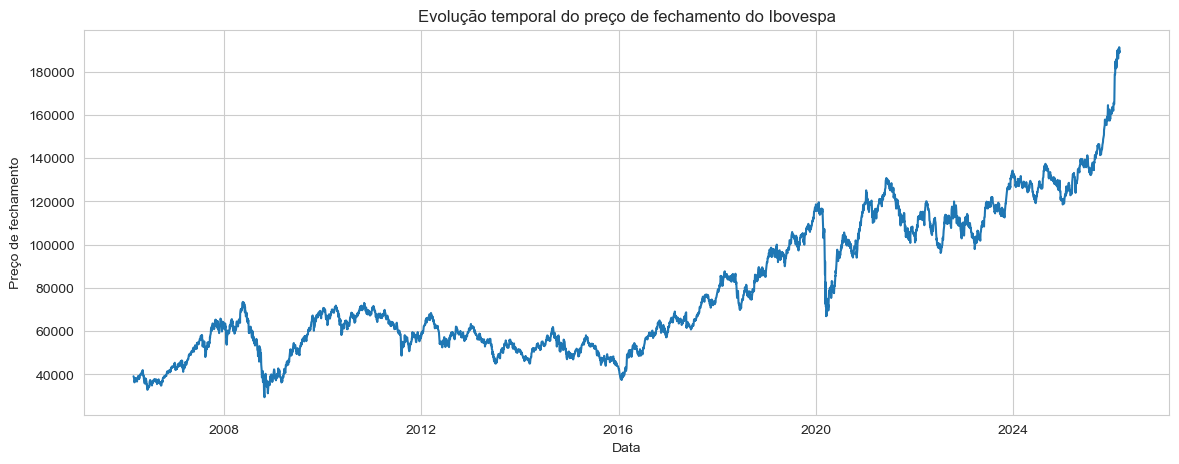

In [9]:
plt.figure(figsize=(14, 5))

df_plot = df[df['Close'] > 20_000]
plt.plot(df_plot.index, df_plot["Close"].values)
plt.title("Evolução temporal do preço de fechamento do Ibovespa")
plt.xlabel("Data")
plt.ylabel("Preço de fechamento")
plt.show()

**Interpretação:**

A série temporal do preço de fechamento do Ibovespa evidencia tendência geral de alta no longo prazo, embora marcada por períodos de correção e maior volatilidade. Observam-se movimentos de valorização, retração e posterior recuperação em diferentes momentos da amostra, refletindo a dinâmica cíclica do mercado ao longo do tempo.

Também é possível identificar mudanças de patamar na série, especialmente nos anos mais recentes, quando o índice passa a operar em níveis historicamente mais elevados. Esse comportamento é consistente com a natureza de séries financeiras de longo horizonte, sujeitas a choques exógenos, mudanças no ambiente macroeconômico e alternância entre diferentes regimes de mercado.

-------------------------------------------

### 9. Definição da Variável Alvo para Classificação (Target)
- **1**: quando o retorno percentual do próximo dia é superior ao limiar estabelecido
- **0**: quando o retorno percentual do próximo dia não supera esse limiar

In [10]:
df["Next_Close"] = df["Close"].shift(-1)
df["Retorno_Pct"] = df["Close"].pct_change().shift(-1)
df["Target"] = (df["Retorno_Pct"] > target_threshold).astype(int)

df[["Close", "Next_Close", "Retorno_Pct", "Target"]].head(10)

,Close,Next_Close,Retorno_Pct,Target
Date,,,,
2006-03-02,39126.0,3924.0,-0.899709,0
2006-03-03,3924.0,38354.0,8.774210,1
2006-03-06,38354.0,37423.0,-0.024274,0
2006-03-07,37423.0,37289.0,-0.003581,0
2006-03-08,37289.0,36312.0,-0.026201,0
2006-03-09,36312.0,36891.0,0.015945,1
2006-03-10,36891.0,36793.0,-0.002656,0
2006-03-13,36793.0,37541.0,0.020330,1
2006-03-14,37541.0,38244.0,0.018726,1


A variável alvo foi construída a partir do retorno percentual do pregão seguinte. Para isso, foi criado o preço de fechamento do próximo dia (`Next_Close`) e, em seguida, calculado o retorno percentual associado. A classificação binária foi definida com base em um limiar mínimo de retorno, em que valores superiores a esse limite recebem classe 1, enquanto os demais recebem classe 0.

--------------------------------------

### 10. Distribuição das Classes da Variável Alvo
Distribuição das classes da variável alvo, com o objetivo de verificar o equilíbrio entre as categorias e identificar possível desbalanceamento, aspecto relevante para a etapa de modelagem preditiva.

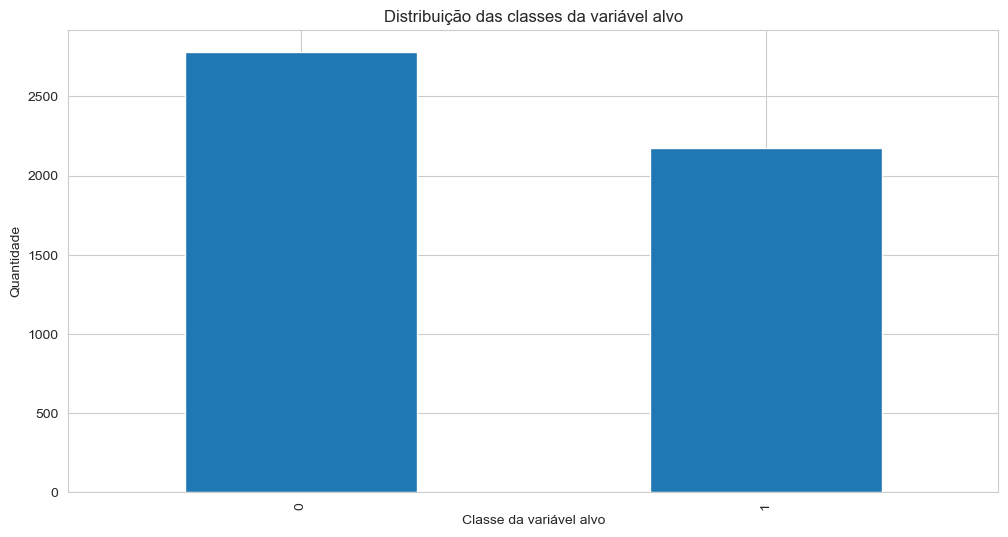

In [11]:
df["Target"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição das classes da variável alvo")
plt.xlabel("Classe da variável alvo")
plt.ylabel("Quantidade")
plt.show()

**Interpretação:**

A distribuição das classes da variável alvo indica predominância da classe 0 em relação à classe 1, caracterizando um leve desbalanceamento na base. Embora essa diferença não seja extrema, ela merece atenção, pois pode influenciar o comportamento do modelo e a interpretação das métricas de desempenho.

Esse resultado é compatível com a regra de construção do alvo, uma vez que a classe 1 corresponde apenas aos casos em que o retorno do próximo pregão supera o limiar mínimo estabelecido, condição naturalmente mais restritiva. Diante desse cenário, torna-se importante acompanhar métricas além da acurácia, como precision, recall e f1-score, para avaliar de forma mais completa a capacidade preditiva do modelo em ambas as classes.

---------------------------------

### 11. Engenharia de Variáveis

#### 11.1. Criação de Variáveis de Retorno e Defasagens Temporais

Criamos as variáveis derivadas com o objetivo de incorporar informações sobre a dinâmica recente da série. Para isso, calcula-se o retorno percentual do preço de fechamento e, em seguida, são geradas defasagens temporais (lags), permitindo que o modelo utilize o comportamento de períodos anteriores como preditores.

In [12]:
# Calcular o retorno percentual diário do preço de fechamento
df["Ret"] = df["Close"].pct_change() * 100

# Criar variáveis defasadas (lags) do retorno para incorporar memória temporal ao modelo
for k in [1, 2, 3, 5, 10]:
    df[f"Ret_lag_{k}"] = df["Ret"].shift(k)

df.filter(like="Ret").head(10)

,Retorno_Pct,Ret,Ret_lag_1,Ret_lag_2,Ret_lag_3,Ret_lag_5,Ret_lag_10
Date,,,,,,,
2006-03-02,-0.899709,NaN,NaN,NaN,NaN,NaN,NaN
2006-03-03,8.774210,-89.970863,NaN,NaN,NaN,NaN,NaN
2006-03-06,-0.024274,877.420999,-89.970863,NaN,NaN,NaN,NaN
2006-03-07,-0.003581,-2.427387,877.420999,-89.970863,NaN,NaN,NaN
2006-03-08,-0.026201,-0.358069,-2.427387,877.420999,-89.970863,NaN,NaN
2006-03-09,0.015945,-2.620076,-0.358069,-2.427387,877.420999,NaN,NaN
2006-03-10,-0.002656,1.594514,-2.620076,-0.358069,-2.427387,-89.970863,NaN
2006-03-13,0.020330,-0.265647,1.594514,-2.620076,-0.358069,877.420999,NaN
2006-03-14,0.018726,2.032995,-0.265647,1.594514,-2.620076,-2.427387,NaN


As variáveis criadas nesta etapa têm como objetivo representar o comportamento recente da série de fechamento. A variável **Ret** corresponde ao retorno percentual diário do índice, enquanto as variáveis **Ret_lag_1**, **Ret_lag_2**, **Ret_lag_3**, **Ret_lag_5** e **Ret_lag_10** representam versões defasadas desse retorno, isto é, os retornos observados em períodos anteriores.

Essas defasagens permitem incorporar informação histórica ao conjunto de preditores, o que é especialmente relevante em problemas de séries temporais, nos quais o comportamento passado pode contribuir para a previsão dos movimentos futuros.
- **Ret**: retorno percentual diário do preço de fechamento
- **Ret_lag_1**: retorno percentual do dia anterior
- **Ret_lag_2**: retorno percentual de dois dias antes
- **Ret_lag_3**: retorno percentual de três dias antes
- **Ret_lag_5**: retorno percentual de cinco dias antes
- **Ret_lag_10**: retorno percentual de dez dias antes

#### 11.2. Criação de Médias Móveis e Medidas de Distanciamento
Construídos indicadores técnicos baseados em médias móveis simples e exponenciais, além de variáveis que medem o distanciamento do preço de fechamento em relação a essas médias. Essas variáveis ajudam a representar tendências de curto e médio prazo, bem como o posicionamento relativo do preço na série.

In [13]:
# Calcular médias móveis simples de 5, 10 e 20 períodos
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()

# Calcular médias móveis exponenciais de 10 e 20 períodos
df["EMA_10"] = df["Close"].ewm(span=10).mean()
df["EMA_20"] = df["Close"].ewm(span=20).mean()

# Calcular a distância relativa do preço de fechamento em relação às médias móveis simples
df["Dist_SMA5"] = (df["Close"] - df["SMA_5"]) / df["SMA_5"]
df["Dist_SMA20"] = (df["Close"] - df["SMA_20"]) / df["SMA_20"]

df[["SMA_5", "SMA_10", "SMA_20", "EMA_10", "EMA_20", "Dist_SMA5", "Dist_SMA20"]].tail()

,SMA_5,SMA_10,SMA_20,EMA_10,EMA_20,Dist_SMA5,Dist_SMA20
Date,,,,,,,
2026-02-24,154617.2,170918.5,168480.55,152099.803093,158285.222646,-0.876152,-0.886343
2026-02-25,155663.4,171419.1,169106.85,159217.475258,161424.439537,0.228593,0.130924
2026-02-26,156157.6,171926.7,169561.15,164997.025211,164241.635771,0.223155,0.126467
2026-02-27,155808.2,171835.5,169765.95,169322.475173,166579.289507,0.211663,0.112043
2026-03-02,155899.0,171989.6,170074.60,172956.025141,168743.833364,0.214293,0.113082


Foram criadas médias móveis simples (**SMA_5**, **SMA_10** e **SMA_20**) e exponenciais (**EMA_10** e **EMA_20**) com o objetivo de representar a tendência recente do preço de fechamento em diferentes horizontes temporais. Além disso, foram construídas variáveis de distanciamento relativo (**Dist_SMA5** e **Dist_SMA20**), que indicam o posicionamento atual do preço em relação às médias móveis simples.

Essas variáveis são úteis para capturar padrões de tendência, suavizar oscilações de curto prazo e fornecer ao modelo informações adicionais sobre o comportamento relativo da série ao longo do tempo.
- **SMA_5**: média móvel simples dos últimos 5 períodos
- **SMA_10**: média móvel simples dos últimos 10 períodos
- **SMA_20**: média móvel simples dos últimos 20 períodos
- **EMA_10**: média móvel exponencial de 10 períodos
- **EMA_20**: média móvel exponencial de 20 períodos
- **Dist_SMA5**: distância relativa entre o preço atual e a SMA de 5 períodos
- **Dist_SMA20**: distância relativa entre o preço atual e a SMA de 20 períodos

#### 11.3. Criação de Variáveis de Momentum e Volatilidade
Construídas variáveis destinadas a capturar a intensidade do movimento recente dos preços e o nível de variabilidade da série ao longo de diferentes janelas temporais. Essas informações podem contribuir para que o modelo identifique padrões de aceleração, desaceleração e instabilidade no comportamento do mercado.

In [14]:
# Calcular variáveis de momentum com base na variação do preço de fechamento em diferentes defasagens
df["Momentum_3"] = df["Close"] - df["Close"].shift(3)
df["Momentum_7"] = df["Close"] - df["Close"].shift(7)
df["Momentum_14"] = df["Close"] - df["Close"].shift(14)

# Calcular medidas de volatilidade a partir do desvio-padrão móvel dos retornos percentuais
df["Vol_5"] = df["Close"].pct_change().rolling(5).std()
df["Vol_10"] = df["Close"].pct_change().rolling(10).std()
df["Vol_20"] = df["Close"].pct_change().rolling(20).std()

df[["Momentum_3", "Momentum_7", "Momentum_14", "Vol_5", "Vol_10", "Vol_20"]].tail()

,Momentum_3,Momentum_7,Momentum_14,Vol_5,Vol_10,Vol_20
Date,,,,,,
2026-02-24,-169385.0,-170550.0,-163644.0,0.403417,2.947634,2.091843
2026-02-25,713.0,3481.0,5573.0,4.136561,2.887024,2.839645
2026-02-26,2152.0,4541.0,9297.0,4.138004,2.887011,2.839933
2026-02-27,169638.0,2771.0,6660.0,4.140173,2.887998,2.840340
2026-03-02,-1940.0,773.0,171012.0,4.139042,2.887594,2.840170


Foram criadas variáveis de momentum e volatilidade com o objetivo de enriquecer a representação da dinâmica da série temporal. As variáveis de momentum (**Momentum_3**, **Momentum_7** e **Momentum_14**) medem a diferença entre o preço atual e o preço observado em períodos anteriores, permitindo capturar a direção e a intensidade do movimento recente.

Já as variáveis de volatilidade (**Vol_5**, **Vol_10** e **Vol_20**) correspondem ao desvio-padrão móvel dos retornos percentuais em diferentes janelas temporais, fornecendo ao modelo uma medida do nível recente de oscilação do mercado.
- **Momentum_3**: diferença entre o preço atual e o preço de 3 períodos atrás
- **Momentum_7**: diferença entre o preço atual e o preço de 7 períodos atrás
- **Momentum_14**: diferença entre o preço atual e o preço de 14 períodos atrás
- **Vol_5**: volatilidade dos retornos em janela de 5 períodos
- **Vol_10**: volatilidade dos retornos em janela de 10 períodos
- **Vol_20**: volatilidade dos retornos em janela de 20 períodos

#### 11.4. Criação do Índice de Força Relativa (RSI)
Calculado o Índice de Força Relativa (RSI), um indicador técnico amplamente utilizado para mensurar a intensidade dos movimentos recentes de alta e de baixa. Essa variável pode contribuir para a identificação de condições de sobrecompra, sobrevenda e mudanças no equilíbrio entre pressão compradora e vendedora.

In [15]:
# Calcular a variação diária do preço de fechamento
delta = df["Close"].diff()

# Separar os movimentos positivos e negativos da série
up = delta.clip(lower=0).rolling(14).mean() # mantém apenas os ganhos, substituindo perdas por 0
down = (-delta.clip(upper=0)).rolling(14).mean() # mantém apenas as perdas, substituindo ganhos por 0 e invertendo o sinal para positivo

# Calcular a razão entre ganhos médios e perdas médias
rs = up / down

# Calcular o RSI de 14 períodos
df["RSI_14"] = 100 - (100 / (1 + rs))

# Visualizar a variável criada
df[["Close", "RSI_14"]].tail()

,Close,RSI_14
Date,,
2026-02-24,19149.0,34.346638
2026-02-25,191247.0,50.402715
2026-02-26,191005.0,50.675453
2026-02-27,188787.0,50.482606
2026-03-02,189307.0,66.234536


Foi criado o indicador técnico **RSI_14** (Relative Strength Index), calculado a partir da razão entre os ganhos médios e as perdas médias observadas em uma janela de 14 períodos. Esse indicador busca representar a força relativa dos movimentos recentes da série, fornecendo uma medida do equilíbrio entre pressão compradora e vendedora.

Como variável preditora, o RSI pode ser útil para capturar momentos de aceleração, exaustão ou reversão no comportamento do preço, complementando outras features baseadas em retorno, tendência e volatilidade.

- **delta**: variação diária do preço de fechamento
- **up**: média móvel dos ganhos em 14 períodos
- **down**: média móvel das perdas em 14 períodos
- **rs**: razão entre ganhos médios e perdas médias
- **RSI_14**: índice de força relativa calculado em 14 períodos

#### 11.5.  Criação do Moving Average Convergence Divergence (MACD)
Construído o indicador MACD (Moving Average Convergence Divergence), amplamente utilizado na análise de séries financeiras para capturar mudanças de tendência e intensidade do movimento dos preços. O indicador é obtido a partir da diferença entre duas médias móveis exponenciais com janelas distintas.

In [16]:
# Calcular a média móvel exponencial curta do preço de fechamento
ema_fast = df["Close"].ewm(span=12).mean()

# Calcular a média móvel exponencial longa do preço de fechamento
ema_slow = df["Close"].ewm(span=26).mean()

# Calcular o MACD como a diferença entre as médias exponenciais curta e longa
df["MACD"] = ema_fast - ema_slow

df[["Close", "MACD"]].tail()

,Close,MACD
Date,,
2026-02-24,19149.0,-2620.519112
2026-02-25,191247.0,463.135922
2026-02-26,191005.0,2854.522220
2026-02-27,188787.0,4518.650833
2026-03-02,189307.0,5812.442187


Foi criado o indicador **MACD**, calculado como a diferença entre a média móvel exponencial de 12 períodos e a média móvel exponencial de 26 períodos. Essa variável busca representar a convergência ou divergência entre tendências de curto e médio prazo, podendo fornecer sinais sobre mudanças na direção ou na intensidade do movimento dos preços.

- **ema_fast**: média móvel exponencial de 12 períodos
- **ema_slow**: média móvel exponencial de 26 períodos
- **MACD**: diferença entre a EMA de 12 períodos e a EMA de 26 períodos

#### 11.6. Criação do Indicador Bollinger %B
Calculado o indicador Bollinger %B, que mede a posição relativa do preço de fechamento dentro das Bandas de Bollinger. Essa variável permite avaliar se o preço está mais próximo da banda inferior, da banda superior ou de uma posição intermediária, contribuindo para a identificação de contextos de pressão compradora ou vendedora.

In [17]:
# Calcular a média móvel central das Bandas de Bollinger
bb_mid = df["Close"].rolling(20).mean()

# Calcular o desvio-padrão móvel em 20 períodos
bb_std = df["Close"].rolling(20).std()

# Definir a banda superior e a banda inferior
bb_up = bb_mid + 2 * bb_std
bb_low = bb_mid - 2 * bb_std

# Calcular o Bollinger %B, que representa a posição relativa do preço dentro das bandas
df["BB_pctB"] = (df["Close"] - bb_low) / (bb_up - bb_low)

df[["Close", "BB_pctB"]].tail()

,Close,BB_pctB
Date,,
2026-02-24,19149.0,-0.227587
2026-02-25,191247.0,0.607439
2026-02-26,191005.0,0.603740
2026-02-27,188787.0,0.591893
2026-03-02,189307.0,0.592730


Foi criado o indicador **BB_pctB**, calculado a partir da posição do preço de fechamento em relação às Bandas de Bollinger. Essa variável expressa, em termos relativos, onde o preço se encontra dentro do intervalo definido pela média móvel central e pelos limites superior e inferior ajustados pela volatilidade recente.

Como feature, o Bollinger %B pode contribuir para capturar contextos de alongamento, compressão e posicionamento relativo do preço, complementando outros indicadores de tendência, momentum e volatilidade.

- **bb_mid**: média móvel simples de 20 períodos
- **bb_std**: desvio-padrão móvel de 20 períodos
- **bb_up**: banda superior de Bollinger
- **bb_low**: banda inferior de Bollinger
- **BB_pctB**: posição relativa do preço dentro das Bandas de Bollinger

#### 11.7. Criação do Oscilador Estocástico %K

Calculado o indicador estocástico %K, que mede a posição relativa do preço de fechamento em relação à faixa de variação recente do mercado. Esse indicador é utilizado para avaliar o grau de proximidade do preço atual em relação às máximas e mínimas observadas em uma janela definida.

In [18]:
# Calcular a mínima dos últimos 14 períodos
lowest_low = df["Low"].rolling(14).min()

# Calcular a máxima dos últimos 14 períodos
highest_high = df["High"].rolling(14).max()

# Calcular o Estocástico %K com base na posição do fechamento dentro da faixa recente
df["StochK"] = 100 * (df["Close"] - lowest_low) / (highest_high - lowest_low)

df[["Close", "StochK"]].tail()

,Close,StochK
Date,,
2026-02-24,19149.0,9.099908
2026-02-25,191247.0,99.278139
2026-02-26,191005.0,99.151276
2026-02-27,188787.0,97.988540
2026-03-02,189307.0,98.261139


Foi criado o indicador **StochK**, correspondente ao Oscilador Estocástico %K de 14 períodos. Essa variável mede a posição relativa do preço de fechamento em relação à faixa delimitada pela mínima e pela máxima recentes, fornecendo ao modelo uma noção do posicionamento atual do preço dentro do intervalo de oscilação mais recente do mercado.

- **lowest_low**: menor valor de Low nos últimos 14 períodos
- **highest_high**: maior valor de High nos últimos 14 períodos
- **StochK**: posição relativa do fechamento dentro da faixa de preço recente

#### 11.8. Criação de Variáveis de Tendência, Estrutura do Candle e Sazonalidade Calendária

Criadas variáveis adicionais com o objetivo de representar a direção da tendência de curto prazo, características intradiárias do candle e componentes temporais associados ao calendário. Essas features ampliam a capacidade do modelo de capturar padrões estruturais e sazonais presentes na série.

In [19]:
# Criar uma variável binária de tendência com base na relação entre médias móveis de curto e médio prazo
df["Trend"] = (df["SMA_5"] > df["SMA_20"]).astype(int)

# Calcular a amplitude diária do candle
df["Range"] = df["High"] - df["Low"]

# Calcular o corpo do candle como a diferença entre fechamento e abertura
df["Body"] = df["Close"] - df["Open"]

# Extrair variáveis de calendário a partir do índice temporal
df["dow"] = df.index.dayofweek
df["month"] = df.index.month

df[["Trend", "Range", "Body", "dow", "month"]].tail()

,Trend,Range,Body,dow,month
Date,,,,,
2026-02-24,0,2927.0,-169705.0,1,2
2026-02-25,0,2205.0,-244.0,2,2
2026-02-26,0,3001.0,-243.0,3,2
2026-02-27,0,2527.0,-2218.0,4,2
2026-03-02,0,-167627.0,521.0,0,3


Foram criadas variáveis complementares para representar diferentes dimensões do comportamento da série. A variável **Trend** sintetiza a direção da tendência com base na relação entre médias móveis de curto e médio prazo. Já **Range** e **Body** capturam características intradiárias do candle, relacionadas à amplitude e ao movimento líquido do pregão.

Além disso, as variáveis **dow** e **month** incorporam informações de calendário, permitindo ao modelo explorar possíveis padrões sazonais associados ao dia da semana e ao mês do ano.

- **Trend**: indicador binário de tendência com base na relação entre **SMA_5** e **SMA_20**
- **Range**: amplitude diária do candle (**High - Low**)
- **Body**: corpo do candle (**Close - Open**)
- **dow**: dia da semana da observação
- **month**: mês da observação

----------------------------------------------

### 12. Análise Gráfica das Features

#### 12.1. Análise do RSI_14 ao Longo do Tempo
Analisado o comportamento temporal do indicador RSI_14, com destaque para as regiões tradicionalmente associadas a sobrecompra e sobrevenda. A visualização permite observar a frequência com que o indicador atinge essas faixas e como esse comportamento se distribui ao longo da série histórica.

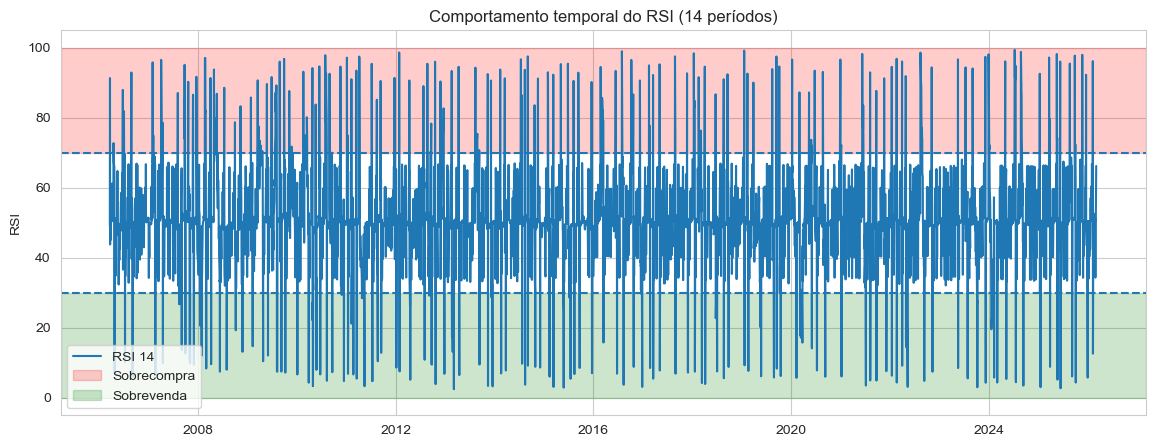

In [20]:
plt.figure(figsize=(14, 5))

# Plotar a série temporal do indicador RSI de 14 períodos
plt.plot(df.index, df["RSI_14"], label="RSI 14")

# Destacar visualmente as regiões de sobrecompra e sobrevenda
plt.axhspan(70, 100, alpha=0.2, label="Sobrecompra", color = 'r')
plt.axhspan(0, 30, alpha=0.2, label="Sobrevenda", color = 'g')

# Adicionar linhas de referência para os limites clássicos do RSI
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("Comportamento temporal do RSI (14 períodos)")
plt.ylabel("RSI")
plt.legend()
plt.show()

**Interpretação:**

O indicador RSI_14 apresenta oscilação frequente em torno da faixa intermediária, especialmente próximo de 50, o que sugere alternância entre pressão compradora e vendedora ao longo do período analisado. Em diversos momentos, o índice também ultrapassa os limites clássicos de 70 e 30, caracterizando situações de sobrecompra e sobrevenda, respectivamente.

Esse comportamento indica que a série apresenta movimentos recorrentes de aceleração e correção no curto prazo, tornando o RSI uma variável potencialmente relevante para capturar desequilíbrios momentâneos na dinâmica dos preços.

#### 12.2. Análise das Médias Móveis sobre o Preço de Fechamento
Analise da relação entre o preço de fechamento e as médias móveis construídas anteriormente. A visualização permite observar o comportamento da série suavizada em diferentes janelas temporais, facilitando a identificação de tendências, mudanças de direção e diferenças de sensibilidade entre os indicadores.

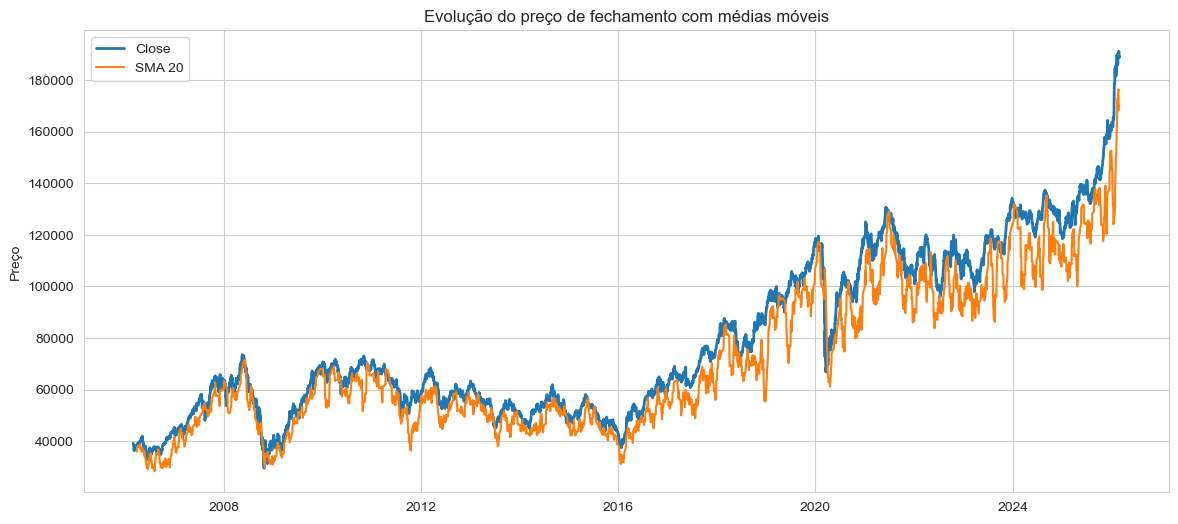

In [21]:
plt.figure(figsize=(14, 6))

df_plot = df[df['Close'] > 20_000]
# Plotar a série do preço de fechamento
plt.plot(df_plot.index, df_plot["Close"].values, label="Close", linewidth=2)

# Plotar as médias móveis simples e exponencial
# plt.plot(df.index, df["SMA_5"], label="SMA 5")
plt.plot(df.index, df["SMA_20"], label="SMA 20")
# plt.plot(df.index, df["EMA_10"], label="EMA 10")

plt.title("Evolução do preço de fechamento com médias móveis")
plt.ylabel("Preço")
plt.legend()

plt.show()

**Interpretação:**

O gráfico compara o preço de fechamento diário do IBOVESPA com a média móvel simples de 20 períodos (SMA 20). A série de fechamento apresenta maior volatilidade, enquanto a SMA 20 atua como suavizador, capturando melhor a direção de curto e médio prazo. Observa-se que a média acompanha o movimento do índice com pequena defasagem, comportamento esperado desse indicador. Em termos analíticos, essa variável é útil para reduzir ruído e destacar mudanças de tendência, sendo relevante para compor a base de atributos do modelo.

#### 12.3. Distribuição das Principais Features Derivadas

Análise das distribuições de algumas das principais variáveis derivadas criadas durante a engenharia de atributos. O objetivo é observar padrões de concentração, dispersão, assimetria e possíveis comportamentos extremos, contribuindo para o entendimento estatístico das features que serão utilizadas na modelagem.

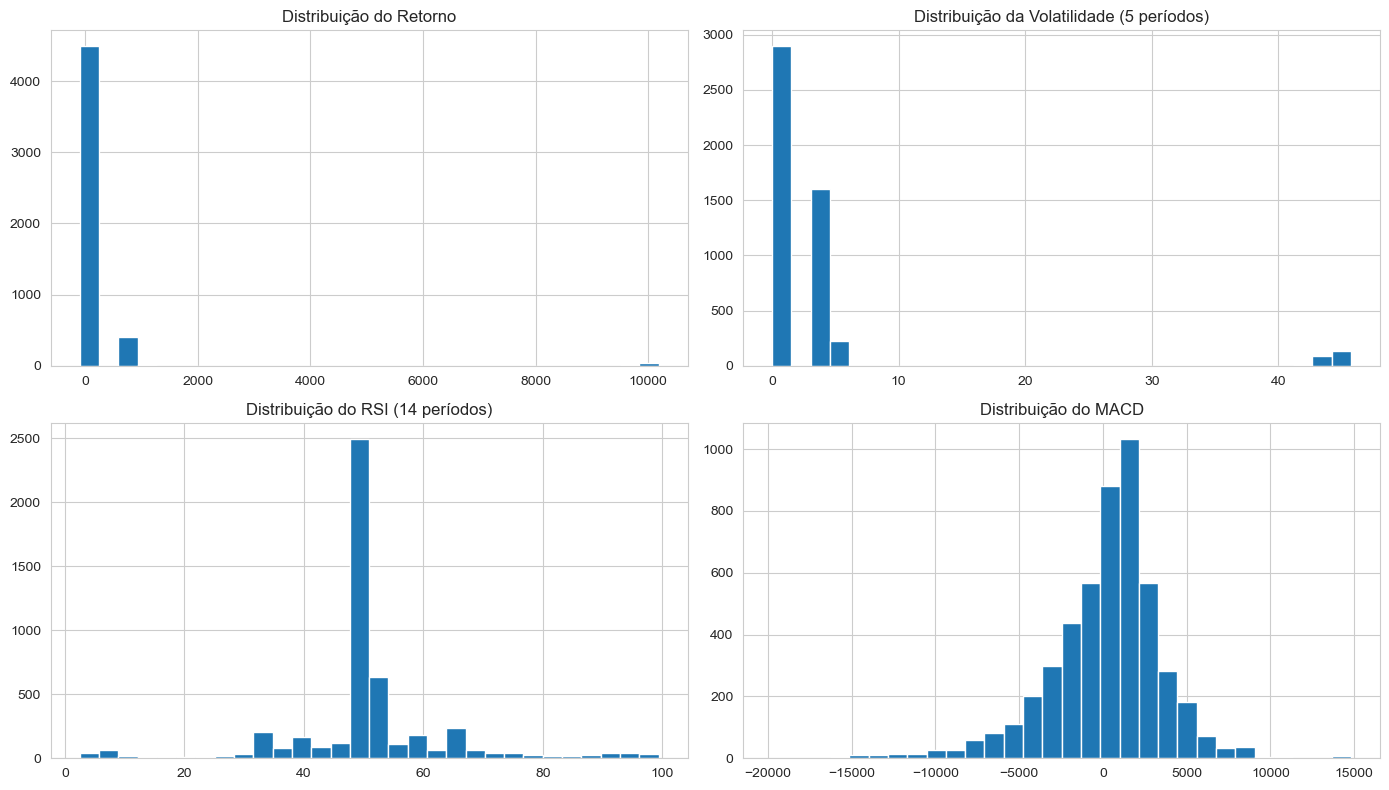

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Distribuição do retorno percentual diário
axes[0, 0].hist(df["Ret"].dropna(), bins=30)
axes[0, 0].set_title("Distribuição do Retorno")

# Distribuição da volatilidade em janela de 5 períodos
axes[0, 1].hist(df["Vol_5"].dropna(), bins=30)
axes[0, 1].set_title("Distribuição da Volatilidade (5 períodos)")

# Distribuição do indicador RSI de 14 períodos
axes[1, 0].hist(df["RSI_14"].dropna(), bins=30)
axes[1, 0].set_title("Distribuição do RSI (14 períodos)")

# Distribuição do indicador MACD
axes[1, 1].hist(df["MACD"].dropna(), bins=30)
axes[1, 1].set_title("Distribuição do MACD")

plt.tight_layout()
plt.show()

**Interpretação:**

As distribuições das features derivadas mostram comportamentos distintos e complementares. A variável de retorno (**Ret**) apresenta forte concentração em torno de zero, indicando que a maior parte das variações diárias do índice ocorre em magnitudes relativamente pequenas, embora existam caudas que refletem episódios de maior intensidade.

A volatilidade de curto prazo (**Vol_5**) exibe assimetria à direita, sugerindo predominância de períodos de menor instabilidade e poucos episódios de oscilação mais intensa. O **RSI_14**, por sua vez, concentra-se majoritariamente na faixa intermediária, especialmente entre níveis próximos de equilíbrio, enquanto o **MACD** apresenta distribuição aproximadamente centrada em torno de zero, o que reforça seu papel como indicador de transição e intensidade de tendência.

-------------------------------------------

### 13. Matriz de Correlação entre Variáveis Numéricas
Analise da correlação linear entre as variáveis numéricas da base. Para facilitar a interpretação, a visualização destaca apenas relações com magnitude igual ou superior ao limite definido, permitindo identificar associações moderadas e fortes entre os atributos.

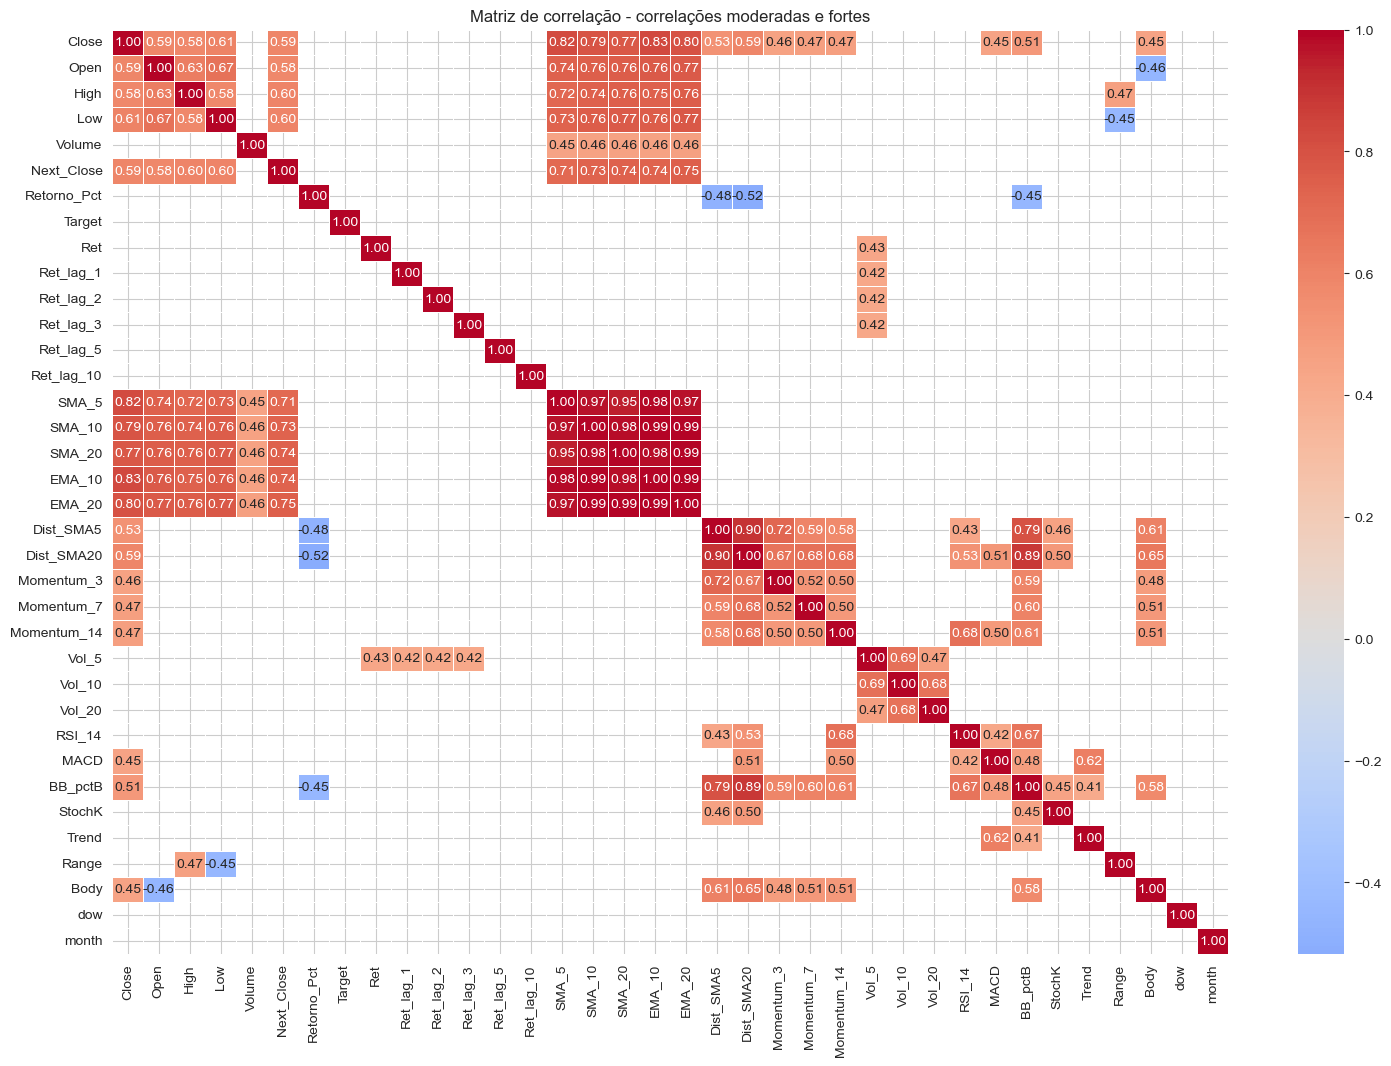

In [23]:
# Selecionar todas as variáveis numéricas da base
cols_numericas = df.select_dtypes(include="number").columns.tolist()

# Calcular a matriz de correlação entre as variáveis numéricas
corr_total = df[cols_numericas].corr()

# Definir o limite mínimo para exibir apenas correlações moderadas e fortes
limite = 0.40
mask = abs(corr_total) < limite

# Plotar o mapa de calor destacando apenas as correlações com magnitude relevante
plt.figure(figsize=(18, 12))
sns.heatmap(
    corr_total,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlação - correlações moderadas e fortes")
plt.show()

**Interpretação:**

A matriz de correlação evidencia a existência de grupos de variáveis com forte associação linear, especialmente entre preços, médias móveis e demais atributos derivados diretamente da série de fechamento. As variáveis **Close**, **Open**, **High**, **Low**, **Next_Close**, **SMA_5**, **SMA_10**, **SMA_20**, **EMA_10** e **EMA_20** apresentam correlações muito elevadas entre si, indicando forte proximidade informacional e possível redundância sob a perspectiva linear.

Também se observam correlações relevantes entre variáveis de volatilidade (**Vol_5**, **Vol_10**, **Vol_20**), entre indicadores técnicos de posicionamento e força (**RSI_14**, **BB_pctB**, **StochK**, **Trend**) e entre **Ret** e **Body**, o que sugere que diferentes features descrevem aspectos semelhantes da dinâmica do mercado. Esse resultado é importante para a etapa de modelagem, pois sinaliza a presença de multicolinearidade e pode orientar decisões futuras de seleção ou simplificação do conjunto de atributos.

----------------------------------------------

### 14. Preparação da Base para Modelagem
A base final para modelagem é estruturada a partir da remoção de registros com valores ausentes e da separação entre variáveis explicativas (**X**) e variável alvo (**y**). Também são excluídas do conjunto preditor variáveis que podem introduzir redundância ou vazamento de informação, preservando apenas atributos numéricos elegíveis para o treinamento dos modelos.

In [24]:
# Remover registros com valores ausentes para compor a base final de modelagem
df_model = df.dropna().copy()

# Verificar a dimensão da base após a remoção de valores ausentes
df_model.shape

(4932, 37)

In [25]:
# Definir o conjunto de variáveis preditoras, excluindo colunas de preço bruto,
# a variável alvo e atributos com potencial de vazamento de informação
X = df_model.drop(
    columns=["Open", "High", "Low", "Close", "Next_Close", "Target", "Retorno_Pct"],
    errors="ignore"
)

# Manter apenas variáveis numéricas no conjunto preditor
X = X.select_dtypes(exclude="object")

# Definir a variável alvo
y = df_model["Target"]

# Verificar as dimensões finais de X e y
print(X.shape)
print(y.shape)

X.head()

(4932, 29)
(4932,)


,Volume,Ret,Ret_lag_1,Ret_lag_2,Ret_lag_3,Ret_lag_5,Ret_lag_10,SMA_5,SMA_10,SMA_20,...,Vol_20,RSI_14,MACD,BB_pctB,StochK,Trend,Range,Body,dow,month
Date,,,,,,,,,,,,,,,,,,,,,
2006-03-30,114600000.0,0.760162,2.208167,-2.547754,0.170317,-0.996011,-0.227487,37433.8,37614.5,35853.65,...,1.982958,57.696317,467.851732,0.563810,62.933827,1,620.0,284.0,3,3
2006-03-31,118950000.0,0.463245,0.760162,2.208167,-2.547754,0.274857,-0.283041,37508.8,37604.8,37555.05,...,1.962129,59.934853,467.513822,0.678154,71.031930,0,397.0,169.0,4,3
2006-04-03,95110000.0,2.015704,0.463245,0.760162,2.208167,0.170317,0.407369,37724.0,37656.1,37573.20,...,0.015662,60.051282,513.681854,0.985147,93.822038,1,899.0,765.0,0,4
2006-04-04,127330000.0,0.219542,2.015704,0.463245,0.760162,-2.547754,-2.109727,38148.0,37796.5,37642.15,...,0.014527,55.332569,549.319931,0.947059,88.186356,1,480.0,84.0,1,4
2006-04-05,158410000.0,0.646874,0.219542,2.015704,0.463245,2.208167,1.211295,38460.2,37916.7,37730.35,...,0.014501,58.302446,588.020241,0.962706,98.627288,1,579.0,250.0,2,4


Após a construção das variáveis derivadas, foi definida a base final de modelagem por meio da remoção de registros com valores ausentes. Em seguida, realizou-se a separação entre o conjunto de variáveis preditoras (**X**) e a variável alvo (**y**).

Do conjunto preditor, foram excluídas variáveis de preço bruto, a variável alvo e atributos diretamente relacionados ao valor futuro da série, como **Next_Close** e **Retorno_Pct**, a fim de evitar vazamento de informação e preservar a consistência do processo preditivo.

--------------------------------------------

### 15. Separação Temporal entre Treino e Teste

In [26]:
# Separar os dados de treino e teste com base na ordem temporal da série
X_train = X.iloc[:-test_size].copy()
y_train = y.iloc[:-test_size].copy()

X_test = X.iloc[-test_size:].copy()
y_test = y.iloc[-test_size:].copy()

# Separar os dados de treino e teste com base na ordem temporal da série
X_train = X_train[X_train.index >= train_start_date]
y_train = y_train[y_train.index >= train_start_date]

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (1504, 29) (1504,)
Teste: (30, 29) (30,)


---------------------------------------------------

### 16. Padronização das Variáveis Preditoras
As variáveis preditoras são padronizadas por meio do **StandardScaler**, de forma que cada atributo passe a apresentar média próxima de zero e desvio-padrão próximo de um no conjunto de treino. Esse procedimento é importante para modelos sensíveis à escala das variáveis, como SVM, e contribui para maior estabilidade no processo de treinamento.

In [27]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

X_train_scaled.head()

,Volume,Ret,Ret_lag_1,Ret_lag_2,Ret_lag_3,Ret_lag_5,Ret_lag_10,SMA_5,SMA_10,SMA_20,...,Vol_20,RSI_14,MACD,BB_pctB,StochK,Trend,Range,Body,dow,month
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,-0.436173,-0.163241,-0.166602,-0.165829,-0.164067,-0.165319,9.656974,0.526239,0.537054,0.096617,...,2.037690,0.090956,1.175488,0.432362,0.224183,0.92563,0.036732,0.070697,0.710760,-1.592742
2020-01-03,-0.435706,-0.166570,-0.163239,-0.166025,-0.165830,-0.164652,-0.166149,0.544356,0.570865,0.125374,...,2.037711,0.081600,1.187881,0.379836,0.220787,0.92563,0.005345,-0.009047,1.419166,-1.592742
2020-01-06,-0.435779,-0.166544,-0.166569,-0.162662,-0.166026,-0.164130,-0.164925,0.541163,0.595664,0.151324,...,2.037721,0.063276,1.169670,0.331143,0.218192,0.92563,0.005068,-0.008456,-1.414455,-1.592742
2020-01-07,-0.436260,-0.166014,-0.166542,-0.165992,-0.162663,-0.165893,-0.164069,0.542421,0.609320,0.172161,...,2.037742,3.477798,1.138052,0.309624,0.217515,0.92563,-0.001900,0.004610,-0.706050,-1.592742
2020-01-08,-0.435963,-0.166188,-0.166012,-0.165965,-0.165992,-0.166089,-0.164855,0.548335,0.615813,0.190586,...,2.037752,1.049419,1.092925,0.282092,0.216216,0.92563,0.009415,0.000177,0.002355,-1.592742


----------------------------------------------------------

### 17. Treinamento e Avaliação do Modelo Random Forest

In [28]:
rf = RandomForestClassifier(
    n_estimators=1500,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features=0.7,
    max_samples=0.8,
    bootstrap=True,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
pred_rf = (proba_rf >= cutoff_proba).astype(int)

acc_rf = accuracy_score(y_test, pred_rf)
hits_rf = (y_test == pred_rf).sum()

print(f"RandomForest: {acc_rf * 100:.2f}% | {hits_rf}/{len(y_test)}")

RandomForest: 73.33% | 22/30


-------------------------------------------------

### 18. Treinamento e Avaliação do Modelo XGBoost

In [29]:
xgb = XGBClassifier(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
pred_xgb = (proba_xgb >= cutoff_proba).astype(int)

acc_xgb = accuracy_score(y_test, pred_xgb)
hits_xgb = (y_test == pred_xgb).sum()

print(f"XGBoost: {acc_xgb * 100:.2f}% | {hits_xgb}/{len(y_test)}")

XGBoost: 80.00% | 24/30


---------------------------------------------------------

### 19. Treinamento e Avaliação do Modelo SVM

In [30]:
svm = SVC(
    kernel="rbf",
    C=20,
    gamma=0.05,
    probability=True,
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

proba_svm = svm.predict_proba(X_test_scaled)[:, 1]
pred_svm = (proba_svm >= cutoff_proba).astype(int)

acc_svm = accuracy_score(y_test, pred_svm)
hits_svm = (y_test == pred_svm).sum()

print(f"SVM: {acc_svm * 100:.2f}% | {hits_svm}/{len(y_test)}")

SVM: 63.33% | 19/30


--------------------------------------

### 20. Comparação de Desempenho entre os Modelos

In [31]:
results = {
    "RandomForest": (acc_rf * 100, hits_rf, len(y_test), rf),
    "XGBoost": (acc_xgb * 100, hits_xgb, len(y_test), xgb),
    "SVM": (acc_svm * 100, hits_svm, len(y_test), svm),
}

for name, (acc, hits, total, _) in results.items():
    print(f"{name}: {acc:.2f}% | {hits}/{total}")

RandomForest: 73.33% | 22/30
XGBoost: 80.00% | 24/30
SVM: 63.33% | 19/30


In [32]:
best_name, (_, _, _, best_model) = max(results.items(), key=lambda x: x[1][0])

print("Melhor modelo:", best_name)

proba_test = best_model.predict_proba(X_test_scaled)[:, 1]

cutoffs = [0.45, 0.48, 0.50, 0.52]

for c in cutoffs:
    pred_test = (proba_test >= c).astype(int)
    acc = accuracy_score(y_test, pred_test)
    print(f"Cutoff {c:.2f}: {acc:.2%}")

Melhor modelo: XGBoost
Cutoff 0.45: 80.00%
Cutoff 0.48: 80.00%
Cutoff 0.50: 80.00%
Cutoff 0.52: 80.00%


----------------------------------

### 21. Seleção do Melhor Modelo

In [33]:
best_name = max(results.items(), key=lambda x: x[1][0])[0]
best_model = results[best_name][3]

print("Melhor modelo:", best_name)

Melhor modelo: XGBoost


--------------------------------------

### 22. Geração do Relatório de Classificação do Melhor Modelo

In [34]:
proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
pred_best = (proba_best >= cutoff_proba).astype(int)

acc = accuracy_score(y_test, pred_best)

print(f'Acurácia: {acc:.4f}\n')
print(classification_report(y_test, pred_best))

Acurácia: 0.8000

              precision    recall  f1-score   support

           0       0.75      0.94      0.83        16
           1       0.90      0.64      0.75        14

    accuracy                           0.80        30
   macro avg       0.82      0.79      0.79        30
weighted avg       0.82      0.80      0.79        30



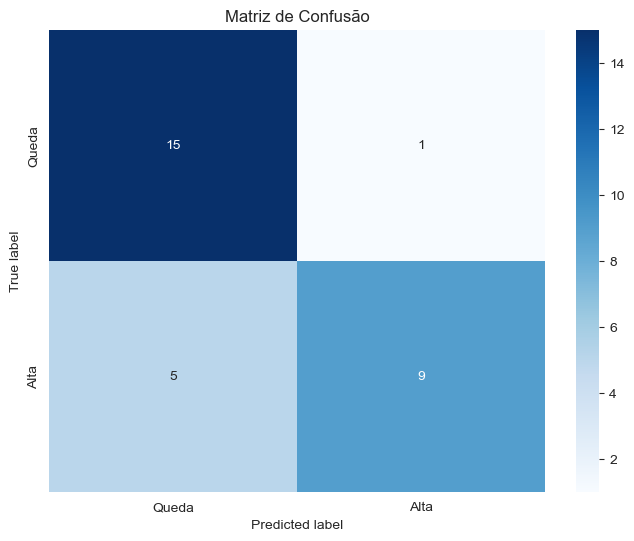

Verdadeiros Negativos: 15
Falsos Positivos: 1
Falsos Negativos: 5
Verdadeiros Positivos: 9


In [35]:
# matriz de confusão
cm = confusion_matrix(y_test, pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Queda", "Alta"],
    yticklabels=["Queda", "Alta"],
    linewidths=0,
)

plt.title("Matriz de Confusão")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()
tn, fp, fn, tp = confusion_matrix(y_test, pred_best).ravel()

print(f"Verdadeiros Negativos: {tn}")
print(f"Falsos Positivos: {fp}")
print(f"Falsos Negativos: {fn}")
print(f"Verdadeiros Positivos: {tp}")

**Interpretação:**

A matriz de confusão mostra que o modelo teve bom desempenho para identificar dias de queda, acertando 15 de 16 casos dessa classe. Para os dias de alta, o desempenho foi um pouco menor, com 9 acertos em 14 casos. No total, o modelo cometeu 6 erros, sendo 1 falso positivo e 5 falsos negativos, o que indica uma tendência maior de classificar alguns dias de alta como queda. Em resumo, o modelo está mais consistente para prever movimentos de baixa do que de alta, mas ainda mantém uma capacidade razoável de separação entre as duas classes.

---------------------------------------------------------

### 23. Consolidação das Previsões Finais no Conjunto de Teste

In [36]:
df_resultado = pd.DataFrame({
    "y_real": y_test,
    "proba": proba_best,
    "y_pred": pred_best
}, index=y_test.index)

df_resultado.tail(30)

,y_real,proba,y_pred
Date,,,
2026-01-15,0,0.336276,0
2026-01-16,1,0.987164,1
2026-01-19,1,0.814299,1
2026-01-20,1,0.245709,0
2026-01-21,1,0.632928,1
2026-01-22,1,0.346489,0
2026-01-23,0,0.270085,0
2026-01-26,1,0.718176,1
2026-01-27,1,0.570433,1


------------------------------------------

### 24. Análise de Overfitting dos Modelos

In [37]:
for name, model in [("RandomForest", rf), ("XGBoost", xgb), ("SVM", svm)]:
    acc_train = accuracy_score(y_train, model.predict(X_train_scaled))
    acc_test  = accuracy_score(y_test,  model.predict(X_test_scaled))
    print(f"{name} — Treino: {acc_train:.2%} | Teste: {acc_test:.2%} | Gap: {acc_train - acc_test:.2%}")

RandomForest — Treino: 99.20% | Teste: 70.00% | Gap: 29.20%
XGBoost — Treino: 100.00% | Teste: 80.00% | Gap: 20.00%
SVM — Treino: 86.90% | Teste: 70.00% | Gap: 16.90%


A comparação entre as acurácias de treino e teste evidencia sinais de overfitting nos modelos exibidos. O Random Forest apresentou 99,20% de acurácia no treino e 70,00% no teste, com gap de 29,20%. Já o XGBoost atingiu 100,00% no treino e 80,00% no teste, com gap de 20,00%. Em ambos os casos, a diferença entre os desempenhos indica perda de generalização em dados não vistos.

Entre os modelos mostrados, o XGBoost apresentou o melhor resultado no conjunto de teste, além de um gap menor que o Random Forest, embora ainda exista sinal de ajuste excessivo ao treino. Esses resultados sugerem que o modelo consegue aprender bem o conjunto de treinamento, mas ainda pode ser aprimorado com técnicas de regularização, ajuste de hiperparâmetros e uma validação temporal mais robusta.

-----------------------------------------------

### 25. Conclusão

Este projeto teve como objetivo construir um modelo de classificação para apoiar a previsão da direção do IBOVESPA no dia seguinte, a partir do histórico do próprio índice. Ao longo do notebook, foram realizadas etapas de carregamento, tratamento, exploração dos dados e engenharia de atributos, com foco em variáveis capazes de representar o comportamento recente da série temporal.

Foram criadas features como retornos defasados, médias móveis, volatilidade, momentum e indicadores técnicos, buscando enriquecer a base de modelagem e capturar diferentes sinais do mercado. Em seguida, foram testados diferentes algoritmos de classificação, comparando seus desempenhos no conjunto de teste separado de forma temporal.

Os resultados mostraram que, entre os modelos avaliados, alguns apresentaram desempenho superior aos demais, embora com indícios de overfitting e espaço para evolução em termos de generalização. Ainda assim, o experimento permitiu estruturar um pipeline coerente de modelagem para séries temporais financeiras, desde a preparação dos dados até a análise comparativa dos modelos.

De forma geral, o trabalho atende à proposta de explorar técnicas preditivas aplicadas ao IBOVESPA e evidencia, na prática, os desafios de prever movimentos diários do mercado utilizando apenas dados históricos do próprio índice. Como continuidade, o projeto pode ser aprimorado com validações temporais mais robustas, novos ajustes de parâmetros e inclusão de variáveis externas que contribuam para ampliar a capacidade preditiva do modelo.